# **Batch Gradient Descent maths**

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## **Manual Calculation Walkthrough: Multiple Linear Regression**
This document demonstrates one full iteration of Batch Gradient Descent for a dataset with 3 features.
1. The Dataset
We are predicting a Test Score based on three inputs.

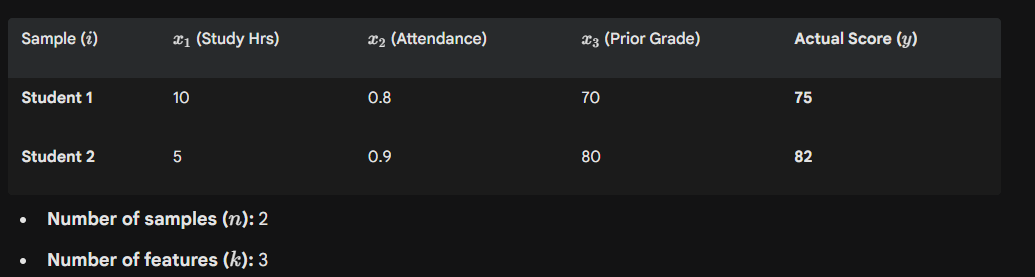

2. Initial Parameters & Hyperparameters
- We start with "placeholder" weights and a small learning rate.
- Weights ($w$): $m_1 = 1.0, \quad m_2 = 1.0, \quad m_3 = 1.0$
- Intercept ($b$): $0.0$
- Learning Rate ($\alpha$): $0.01$

3. Step 1: Forward Pass (Predictions)
We calculate the predicted score ($\hat{y}$) using:
$$\hat{y} = (m_1 \cdot x_1) + (m_2 \cdot x_2) + (m_3 \cdot x_3) + b$$
- Prediction 1 (row 1) ($\hat{y}_1$): $(1.0 \cdot 10) + (1.0 \cdot 0.8) + (1.0 \cdot 70) + 0 = 10.0 + 0.8 + 70.0 = \mathbf{80.8}$
- Prediction 2 (row 2) ($\hat{y}_2$): $(1.0 \cdot 5) + (1.0 \cdot 0.9) + (1.0 \cdot 80) + 0 = 5.0 + 0.9 + 80.0 = \mathbf{85.9}$

4. Step 2: Calculate Residuals (Errors)
The residual is the difference between what we predicted and the actual truth.
$$\text{Error} = \hat{y} - y$$
- Error 1 ($e_1$): $80.8 - 75 = \mathbf{5.8}$
- Error 2 ($e_2$): $85.9 - 82 = \mathbf{3.9}$

5. Step 3: Compute Gradients
The gradient tells us the "slope of the mountain." The formula for the gradient of a coefficient $m_j$ is:
$$\text{Grad}_{m_j} = \frac{2}{n} \sum (\text{Error} \cdot \text{Feature}_j)$$

A. Gradient for Intercept ($b$)
$$\text{Grad}_b = \frac{2}{2} (e_1 + e_2) = (5.8) + (3.9) = \mathbf{9.7}$$

B. Gradient for $m_1$ (Study Hours)
$$\text{Grad}_{m_1} = \frac{2}{2} [(e_1 \cdot x_{1,1}) + (e_2 \cdot x_{2,1})]$$
$$\text{Grad}_{m_1} = [(5.8 \cdot 10) + (3.9 \cdot 5)] = 58.0 + 19.5 = \mathbf{77.5}$$

C. Gradient for $m_2$ (Attendance)
$$\text{Grad}_{m_2} = [(5.8 \cdot 0.8) + (3.9 \cdot 0.9)] = 4.64 + 3.51 = \mathbf{8.15}$$

D. Gradient for $m_3$ (Prior Grade)
$$\text{Grad}_{m_3} = [(5.8 \cdot 70) + (3.9 \cdot 80)] = 406.0 + 312.0 = \mathbf{718.0}$$

6. Step 4: Update Parameters
Finally, we update our old weights to the new, slightly better weights using the update rule:

$$\text{Parameter}_{new} = \text{Parameter}_{old} - (\alpha \cdot \text{Gradient})$$

- New $b$: $0 - (0.01 \cdot 9.7) = \mathbf{-0.097}$
- New $m_1$: $1.0 - (0.01 \cdot 77.5) = \mathbf{0.225}$
- New $m_2$: $1.0 - (0.01 \cdot 8.15) = \mathbf{0.9185}$
- New $m_3$: $1.0 - (0.01 \cdot 718.0) = \mathbf{-6.18}$

In [3]:
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)

print(X.shape)
print(y.shape, '\n')

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


reg = LinearRegression()
reg.fit(X_train,y_train)


print(reg.coef_, '\n')
print(reg.intercept_)




(442, 10)
(442,) 

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238] 

151.88331005254167


In [4]:
class BatchGDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self, X_train, y_train):
        # Initialize coefficients (weights) and intercept (bias)
        # X_train.shape[1] is the number of features
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        # KEEP IN MIND THAT, WHILE DOING BATCH GRADIENT DESCENT, WE INITIALIZE INTERCEPT AS 0 AND COEFFICIENT AS 1 FOR ALL THE FEATURES
        
        m = X_train.shape[0] # Number of samples (n)
        
        for i in range(self.epochs):
            # 1. Calculate prediction: y_hat = Xw + b
            y_hat = np.dot(X_train, self.coef_) + self.intercept_
           
            
            # 2. Calculate gradients using Partial Differentiation
            # Residual (Error) = (y - y_hat)
            residual = y_train - y_hat
            
            # Gradient for intercept (b): -(2/m) * np.sum(residual)
            intercept_der = -2 * np.mean(residual)
            
            # Gradient for coefficients (mj): -(2/m) * (X^T . residual)
            # Transposing X ensures (d, m) dot (m, 1) results in (d, 1)
            coef_der = (-2/m) * np.dot(X_train.T, residual)
            
            # 3. Update weights (Gradient Descent Step)
            # New = Old - (Learning Rate * Direction)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            self.coef_ = self.coef_ - (self.lr * coef_der)
            
        print(f"Final Intercept: {self.intercept_}")
        print(f"Final Coefficients: {self.coef_}")
    
    def predict(self, X_test):
        # Prediction for new data using learned parameters
        return np.dot(X_test, self.coef_) + self.intercept_

In [5]:
print(X_train.shape)
print(np.ones(X_train.shape[1]).shape)
print(np.ones(X_train.shape[1]))
print(np.ones(X_train.shape[0]))
np.ones(X_train.shape[1])

(353, 10)
(10,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


np.dot()

The Math: It follows the "Row times Column" rule. It takes a row of features, 
multiplies each feature by its corresponding weight ($m_1, m_2, ...$), 
and sums them up into a single prediction ($\hat{y}$) for that row.


In [6]:
# -(2/m) * np.sum(y_train - self.coef_*X_train.ravel() - self.intercept_)

In [7]:
bgd = BatchGDRegressor()
bgd.fit(X_train, y_train)

bgd.predict(X_test)

Final Intercept: 130.52896930987225
Final Coefficients: [ 2.63772241  1.19060622  5.06046267  4.31375004  2.44715577  1.99246132
 -1.48838841  3.60218122  5.24193975  3.51394813]


array([130.82561036, 131.45648962, 130.51563837, 129.6924291 ,
       132.21155428, 131.92196772, 129.37122582, 129.52154652,
       129.18247474, 131.19816314, 131.26436024, 130.85520237,
       131.30135107, 130.94419897, 132.0510731 , 129.59780118,
       130.90982452, 129.88193685, 130.44324534, 130.38043632,
       129.61053585, 132.05507184, 131.1925566 , 131.37123461,
       130.04153594, 131.92697347, 131.41246516, 130.49010779,
       128.6524301 , 132.8302861 , 132.32457517, 129.91374064,
       128.81635895, 129.94337674, 131.55265895, 130.85585908,
       131.10894221, 131.69056376, 129.78377331, 132.29392638,
       129.9768549 , 130.12840556, 131.25790055, 131.25971171,
       130.79776836, 130.33699588, 131.108091  , 132.90154638,
       129.96165519, 132.01260926, 132.12398106, 129.57705597,
       130.02257089, 131.00915826, 131.42746797, 129.99487065,
       131.3025268 , 129.30273456, 130.71166975, 129.94986343,
       130.84704345, 131.26143876, 129.91570423, 131.27

In [8]:
# np.dot()

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# 1*4 + 2*5 + 3*6 = 32

result = np.dot(a, b)
print(result)


32
